In [1]:
import numpy as np
import matplotlib.pyplot as plt
import odl

import sys
sys.path.append("..")

from src.tomo import (
    make_space_2d,
    shepp_logan_2d,
    parallel_geom_2d,
    ray_transform_2d,
    reconstruct_bp,
    reconstruct_fbp,
)
space = make_space_2d(Nx=256, Ny=256, domain=[-1, 1, -1, 1])
phantom = shepp_logan_2d(space)
phantom_np = phantom.asarray()

angular_coverage=(-90,90)
step = 1
geom = parallel_geom_2d(angular_coverage=angular_coverage, step=step, 
                        det_range=(-1.5, 1.5), det_count=400)
A = ray_transform_2d(space, geom)
data_space = A.range

sinogram = A(phantom)

from src.tomo import add_poisson_noise, add_gaussian_noise, add_poisson_gaussian_noise

I0 = 2e4
# sino_noisy = add_poisson_noise(sino, A, I0=I0)
# sino_noisy = add_gaussian_noise(sino, A, I0=I0, sigma=3.0)
sino_noisy = add_poisson_gaussian_noise(sinogram, A, I0=I0, sigma=2.0)


/home/ahopkins/KTH_TTMAM/MEX/odl_xray/venv/lib/python3.10/site-packages/odl/util/utility.py:1398: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_requirements


**Find best frequency filter for noise level (best FBP solution)**
* Measured in relative $L^2$-error against the true phantom

In [2]:
from src.metrics import rel_l2_err
# Find the best FBP solution by looping over all filters, measured by relative L2
error = np.inf
for filter in ["Ram-Lak", "Shepp-Logan", "Cosine", "Hamming", "Hann"]:
    temp = reconstruct_fbp(sino_noisy, A, filter_name=filter)
    temp = temp.asarray()
    temp_error = rel_l2_err(x=temp, xtrue=phantom_np)
    if temp_error < error:
        fbp_best = temp
        error = temp_error
        best_filter = filter

# Reference solution is the FBP with ramp filter (Ram-Lak)
fbp_ref = reconstruct_fbp(sino_noisy, A, filter_name="Ram-Lak")
fbp_ref = fbp_ref.asarray()

In [3]:
import odl, inspect
import odl.tomo.analytic.filtered_back_projection as fbpmod
print(odl.__version__)
print(inspect.getsource(fbpmod._fbp_filter))


0.8.3
def _fbp_filter(norm_freq, filter_type, frequency_scaling):
    """Create a smoothing filter for FBP.

    Parameters
    ----------
    norm_freq : `array-like`
        Frequencies normalized to lie in the interval [0, 1].
    filter_type : {'Ram-Lak', 'Shepp-Logan', 'Cosine', 'Hamming', 'Hann',
                   callable}
        The type of filter to be used.
        If a string is given, use one of the standard filters with that name.
        A callable should take an array of values in [0, 1] and return the
        filter for these frequencies.
    frequency_scaling : float
        Scaling of the frequencies for the filter. All frequencies are scaled
        by this number, any relative frequency above ``frequency_scaling`` is
        set to 0.

    Returns
    -------
    smoothing_filter : `numpy.ndarray`

    Examples
    --------
    Create an FBP filter

    >>> norm_freq = np.linspace(0, 1, 10)
    >>> filt = _fbp_filter(norm_freq,
    ...                    filter_ty

### Fixing the ODL internal _fbp_filter
* Fixing it so that it accepts a custom filter

In [4]:
def _fbp_filter_patched(norm_freq, filter_type, frequency_scaling):
    """Create a smoothing filter for FBP.

    Parameters
    ----------
    norm_freq : `array-like`
        Frequencies normalized to lie in the interval [0, 1].
    filter_type : {'Ram-Lak', 'Shepp-Logan', 'Cosine', 'Hamming', 'Hann',
                   callable}
        The type of filter to be used.
        If a string is given, use one of the standard filters with that name.
        A callable should take an array of values in [0, 1] and return the
        filter for these frequencies.
    frequency_scaling : float
        Scaling of the frequencies for the filter. All frequencies are scaled
        by this number, any relative frequency above ``frequency_scaling`` is
        set to 0.

    Returns
    -------
    smoothing_filter : `numpy.ndarray`

    Examples
    --------
    Create an FBP filter

    >>> norm_freq = np.linspace(0, 1, 10)
    >>> filt = _fbp_filter(norm_freq,
    ...                    filter_type='Hann',
    ...                    frequency_scaling=0.8)
    """
    # filter_type, filter_type_in = str(filter_type).lower(), filter_type
    filter_type_in = filter_type    # Add this for error message
    if callable(filter_type):
        filt = filter_type(norm_freq)
    else:   # add else here for string-based call (e.g. "hann")
        filter_type = str(filter_type).lower()
        if filter_type == 'ram-lak':
            filt = np.copy(norm_freq)
        elif filter_type == 'shepp-logan':
            filt = norm_freq * np.sinc(norm_freq / (2 * frequency_scaling))
        elif filter_type == 'cosine':
            filt = norm_freq * np.cos(norm_freq * np.pi / (2 * frequency_scaling))
        elif filter_type == 'hamming':
            filt = norm_freq * (
                0.54 + 0.46 * np.cos(norm_freq * np.pi / (frequency_scaling)))
        elif filter_type == 'hann':
            filt = norm_freq * (
                np.cos(norm_freq * np.pi / (2 * frequency_scaling)) ** 2)
        else:
            raise ValueError('unknown `filter_type` ({})'
                            ''.format(filter_type_in))

    indicator = (norm_freq <= frequency_scaling)
    filt *= indicator
    return filt


# Patch
fbpmod._fbp_filter = _fbp_filter_patched


### Creating the SIAC filter for FBP with ramp

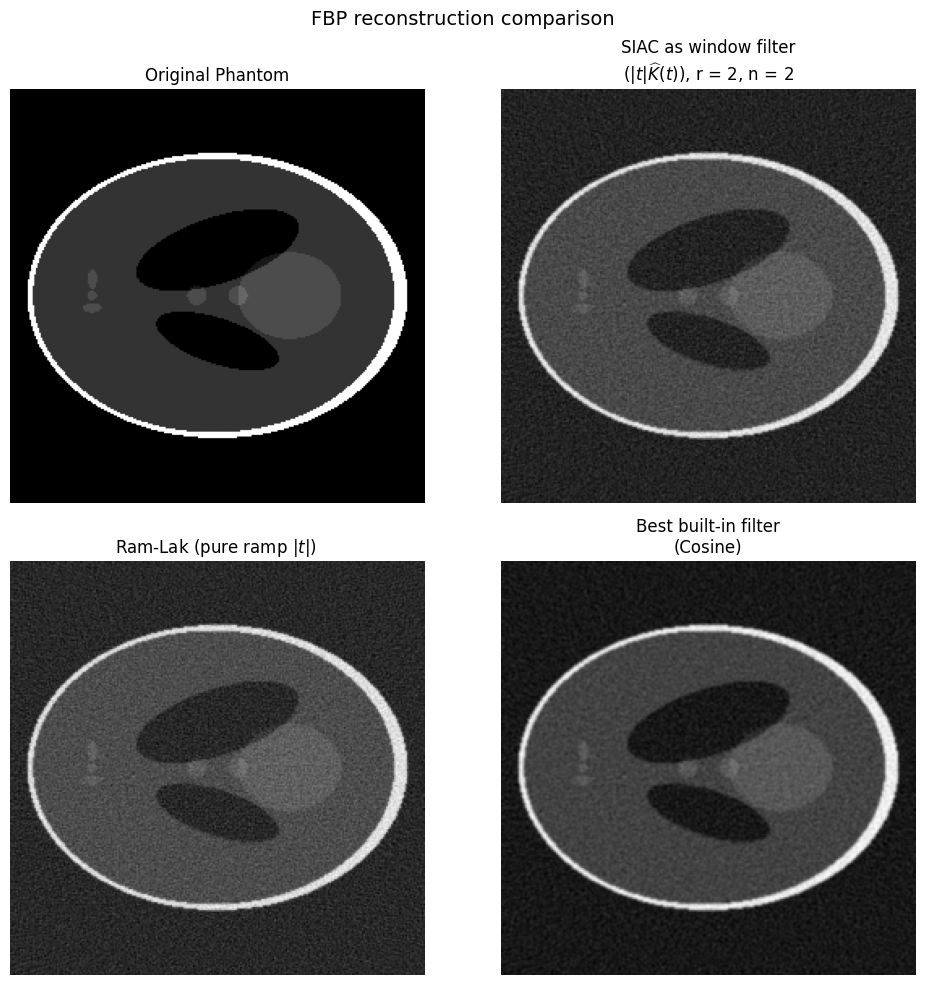

In [12]:
from src.siac import siac_cgam

def siac_filter_odl(moments, BSorder, include_ramp=True):
    cgam = siac_cgam(moments, BSorder)

    def filt(t):
        t = np.asarray(t, dtype=float)
        t = np.clip(t, 0.0, 1.0)

        # Dimensionless frequency
        w = np.pi * t

        # Cosine series
        cterm = cgam[0] * np.ones_like(w)
        for gamma in range(1, len(cgam)):
            cterm += 2.0 * cgam[gamma] * np.cos(gamma * w)

        # B-spline factor
        sinc_term = np.sinc(w / (2.0 * np.pi)) ** BSorder

        Khat = sinc_term * cterm

        if include_ramp:
            return t * Khat   # Ram-Lak x SIAC window
        else:
            return Khat #1-Khat       # SIAC window only
        
    return filt


fbp_best = odl.tomo.fbp_op(
    A,
    filter_type=best_filter,
    padding=True,
    frequency_scaling=1.0
)

moments = 2
BSorder = 2

fbp_siac = odl.tomo.fbp_op(
    A, 
    filter_type = siac_filter_odl(moments=moments, BSorder=BSorder, include_ramp=True), 
    padding=True, 
    frequency_scaling=1.0
)

# make subplots
fbp_img_SIAC = fbp_siac(sino_noisy).asarray()
fbp_img_best = fbp_best(sino_noisy).asarray()
fbp_img_ref = fbp_ref


fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# --- SIAC-based reconstructions ---
axes[0, 0].imshow(phantom_np, cmap="gray")
axes[0, 0].set_title("Original Phantom")
axes[0, 0].axis("off")

axes[0, 1].imshow(fbp_img_SIAC, cmap="gray")
axes[0, 1].set_title(f"SIAC as window filter\n($|t|\widehat K(t)$), r = {moments}, n = {BSorder}")
axes[0, 1].axis("off")

# --- Reference / baseline reconstructions ---
axes[1, 0].imshow(fbp_img_ref, cmap="gray")
axes[1, 0].set_title("Ram-Lak (pure ramp $|t|$) ")
axes[1, 0].axis("off")

axes[1, 1].imshow(fbp_img_best, cmap="gray")
axes[1, 1].set_title(f"Best built-in filter\n({best_filter})")
axes[1, 1].axis("off")

fig.suptitle("FBP reconstruction comparison", fontsize=14)
plt.tight_layout()
plt.show()

plt.show()  # to not get duplicated plots for the last one
